# **0) Imports e setup**

todos os imports usados:

In [ ]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLP / texto
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import string

# Ambiente
from google.colab import drive

# Machine Learning
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
from sklearn.pipeline import make_pipeline


importando dataset do drive

In [ ]:
from google.colab import files
uploaded = files.upload()


# **SESSÃO 1: TRATAMENTO DO DATASET**

# **1) Imports essenciais nessa etapa**

In [ ]:
"""
import pandas as pd
import numpy as np
"""

'\nimport pandas as pd\nimport numpy as np\n'

# **2) Leitura do CSV bruto**

carrega o dataframe.
Em python, chamamos Tabelas de linhas x colunas de dataframe

In [ ]:
reviews = pd.read_csv("/content/drive/MyDrive/seminário 2 bd/dataset.csv")

retorna uma dupla (qnt de linhas , qnt de colunas)

In [ ]:
reviews.shape

(6417106, 5)

mostra as 5 primeiras linhas

In [ ]:
reviews.iloc[5:10]

,app_id,app_name,review_text,review_score,review_votes
5,10,Counter-Strike,"No r8 revolver, 10/10 will play again.",1,1
6,10,Counter-Strike,Still better than Call of Duty: Ghosts...,1,1
7,10,Counter-Strike,"cant buy skins, cases, keys, stickers - gaben ...",1,1
8,10,Counter-Strike,"Counter-Strike: Ok, after 9 years of unlimited...",1,1
9,10,Counter-Strike,Every server is spanish or french. I can now f...,1,0


retorna informações sobre o dataset, data type etc

In [ ]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6417106 entries, 0 to 6417105
Data columns (total 5 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   app_id        int64 
 1   app_name      object
 2   review_text   object
 3   review_score  int64 
 4   review_votes  int64 
dtypes: int64(3), object(2)
memory usage: 244.8+ MB


# **3) tratamento básico dos dados**

Aqui filtramos só as colunas que vamos usar em nossa análise, sem precisar trabalhar com todas agora

In [ ]:
reviews2 = reviews[['review_score','review_text']]

isnull retorna as linhas que possuem NULL como valor, a função sum soma. Fazemos isso para verificar se temos que limpar essas linhas nulas antes de seguir


In [ ]:
reviews2.isnull().sum()

,0
review_score,0
review_text,7305


Remove qualquer linha que tenha valor NULL em qualquer uma das duas colunas (`review_score` ou `review_text`).
`inplace=True` aplica direto no reviews2 sem criar cópia.

In [ ]:
reviews2.dropna(inplace = True)

/tmp/ipython-input-4098535159.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reviews2.dropna(inplace = True)


`Review_score` é a coluna que indica se o usuario que fez a review recomenda o jogo ou não. Caso seja `-1`, não recomenda, caso contrário, `1`.


Aqui, vamos listar os valores distintos da coluna. O método `.unique()` retorna um vetor com os valores únicos da coluna.

Aqui ele confirma que os rótulos são numéricos e binários `(típico: -1 e 1)`.
Bom para evitar surpresas, tipo rótulo “0” perdido ou string.

In [ ]:
reviews2['review_score'].unique()

array([ 1, -1])

Elimina linhas idênticas `(texto + score iguais)`. Ajuda a não viciar métricas com repetições.

`review_score` = `-1` significa review negativa (o usuário não recomenda o jogo)

`review_score` = `1` significa review positiva ( o usuário recomenda o jogo)

In [ ]:
reviews2.drop_duplicates(inplace=True)

/tmp/ipython-input-640875315.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reviews2.drop_duplicates(inplace=True)


# **4) Amostragem para reduzir o volume**

Agora, para poder explorar e treinar o modelo, selecionamos uma amostra aleatória do dataset. Para isso, usamos o metodo .`sample`:

In [ ]:
new_df = reviews2.sample(n = 50000)

Aqui convém selecionar uma amostra para explorar e treinar o modelo.

O dataset original tem milhões de linhas; usamos uma amostra de `50k` apenas para viabilizar o experimento dentro do tempo e da memória disponíveis

Como o dataframe original é grande igual a dor de torcer pro cruzeiro entre 2019 e 2023,
convém poupar nossa RAM de lidar com ele sempre.

In [ ]:
new_df.shape

(50000, 2)

In [ ]:
new_df.isnull().sum()

,0
review_score,0
review_text,0


In [ ]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 6038558 to 2337028
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   review_score  50000 non-null  int64 
 1   review_text   50000 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.1+ MB


Mudando os nomes das colunas das amostras:
`score = target`  e `review_text = text`

In [ ]:
new_df.rename(columns={'review_score':'target','review_text':'text'},inplace=True)


# **SESSÃO 2: ANÁLISE EXPLORATÓRIA DOS DADOS (EDA)**

O objetivo da EDA aqui é entender o tamanho típico das reviews e se há alguma diferença grosseira entre textos positivos e negativos. Não estamos tentando ‘separar’ as classes só por comprimento.

Importações necessárias

In [ ]:
"""
from matplotlib import pyplot as plt
import nltk

"""

'\nfrom matplotlib import pyplot as plt\nimport nltk\n\n'

# **1) Contagem de rótulos**

quantas reviews autointitulados pelos users positivas ou negativas existem?

In [ ]:
new_df['target'].value_counts()

,count
target,
1,40908
-1,9092


Plotaremos um gráfico de pizza do desbalanceamento

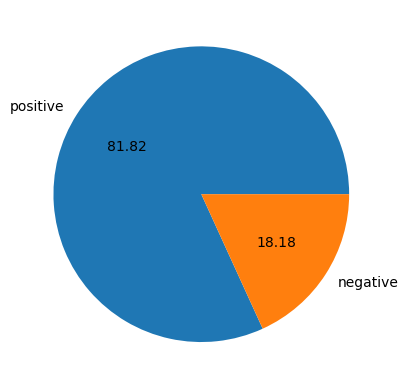

In [ ]:
plt.pie(new_df['target'].value_counts(),labels=['positive','negative'],autopct='%0.2f')
plt.show()

# **CRIANDO DADOS A PARTIR DAS COLUNAS**

Baixa o pacote `punkt` (tokenizador de sentenças/palavras). Sem isso, `nltk`.`word_tokenize` e `nltk.sent_tokenize` podem quebrar.

In [ ]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

# **2) Número de caracteres por review:**

Cria a coluna char_num com o comprimento do texto em caracteres.

In [ ]:
new_df['char_num'] = new_df['text'].apply(len)

In [ ]:
new_df.head()

,target,text,char_num
6038558,1,i learned more russian playing 18 hrs than 4 y...,80
3755002,1,All I have to say is this game is amazing!!!!,45
1109815,-1,Update! Overkill have decided that any brainl...,3993
5365130,1,*teleports behind you* MIETA 10/10,34
877802,1,An unbelievably deep and rewarding game. I can...,77


# **3) Número de palavras por review**

In [ ]:
#word nums
new_df['word_num'] = new_df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
new_df.head()

,target,text,char_num,word_num
6038558,1,i learned more russian playing 18 hrs than 4 y...,80,17
3755002,1,All I have to say is this game is amazing!!!!,45,14
1109815,-1,Update! Overkill have decided that any brainl...,3993,798
5365130,1,*teleports behind you* MIETA 10/10,34,7
877802,1,An unbelievably deep and rewarding game. I can...,77,15


`nltk.word_tokenize(x)`: tokeniza cada texto em palavras.

`len(...)`: conta tokens e guarda em word_num.

Outro `head()` para conferência.

# **4) Número de sentenças por review:**

In [ ]:
#num of sentences
new_df['sent_num'] = new_df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
new_df.head()


,target,text,char_num,word_num,sent_num
6038558,1,i learned more russian playing 18 hrs than 4 y...,80,17,2
3755002,1,All I have to say is this game is amazing!!!!,45,14,2
1109815,-1,Update! Overkill have decided that any brainl...,3993,798,35
5365130,1,*teleports behind you* MIETA 10/10,34,7,1
877802,1,An unbelievably deep and rewarding game. I can...,77,15,2


`nltk.sent_tokenize(x)`: separa o texto em sentenças.

`len(...)`: conta sentenças e salva em sent_num.

`head()` de novo para ver se ficou certo.

# **ESTÁTISTICA**

# **5) estátistica descritiva geral**

In [ ]:
new_df[['char_num','word_num','sent_num']].describe()


,char_num,word_num,sent_num
count,50000.000000,50000.00000,50000.000000
mean,386.594400,81.22920,4.534220
std,670.178662,142.25863,6.536761
min,1.000000,1.00000,1.000000
25%,67.000000,15.00000,1.000000
50%,161.000000,34.00000,2.000000
75%,410.000000,86.00000,5.000000
max,8000.000000,7913.00000,241.000000


Estatísticas básicas de dispersão ou tendencia central (média, desvio, quartis, etc.) dessas três features de tamanho.

#**6) Est. Descritiva por tipo**

In [ ]:
#neg. reviews description
new_df[new_df['target'] == -1][['char_num','word_num','sent_num']].describe()

,char_num,word_num,sent_num
count,9092.000000,9092.000000,9092.000000
mean,505.390013,106.083590,5.605917
std,817.322888,168.871982,7.871416
min,3.000000,1.000000,1.000000
25%,88.000000,19.000000,1.000000
50%,222.000000,47.000000,3.000000
75%,559.000000,118.000000,6.000000
max,7999.000000,1704.000000,107.000000


Filtra apenas negativas e roda `describe()` para comparar com o geral.

In [ ]:
#pos. reviews description
new_df[new_df['target'] == 1][['char_num','word_num','sent_num']].describe()

,char_num,word_num,sent_num
count,40908.000000,40908.000000,40908.000000
mean,360.191503,75.705192,4.296030
std,629.820846,135.018646,6.176139
min,1.000000,1.000000,1.000000
25%,64.000000,14.000000,1.000000
50%,150.000000,32.000000,2.000000
75%,380.000000,80.000000,5.000000
max,8000.000000,7913.000000,241.000000


Mesma coisa para positivas. A ideia é ver se textos positivos tendem a ser mais longos/curtos que negativos.

**Import do seaborn**

In [ ]:
#import seaborn as sns

Traz o Seaborn para plots mais bonitinhos. Nada especial aqui.

#**7) Histogramas comparando classes**

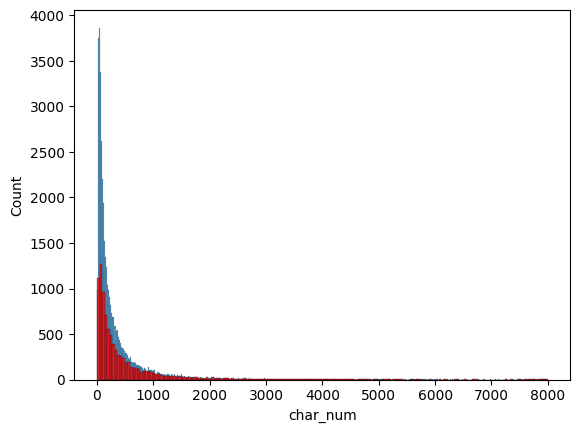

In [ ]:
sns.histplot(new_df[new_df['target'] == 1]['char_num'])
sns.histplot(new_df[new_df['target'] == -1]['char_num'],color='red')

plt.show()

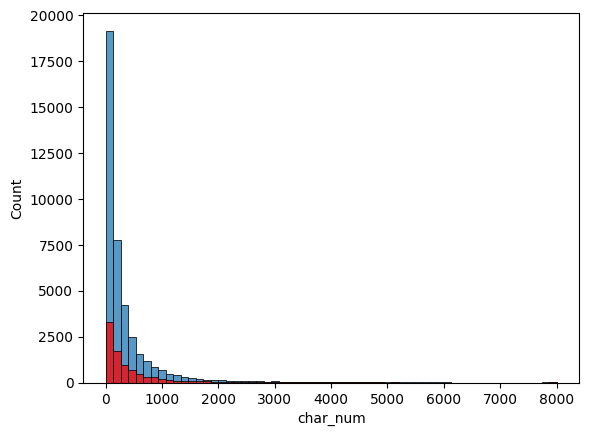

In [ ]:
#Versão limitando intervalo do eixo X para melhor visualização:
sns.histplot(new_df[new_df['target'] == 1]['char_num'], bins=60)
sns.histplot(new_df[new_df['target'] == -1]['char_num'], bins=60, color='red')

plt.show()

Dois histplot sobrepostos: positivos em padrão, negativos em vermelho, para `char_num`.

`plt.show()`: exibe.

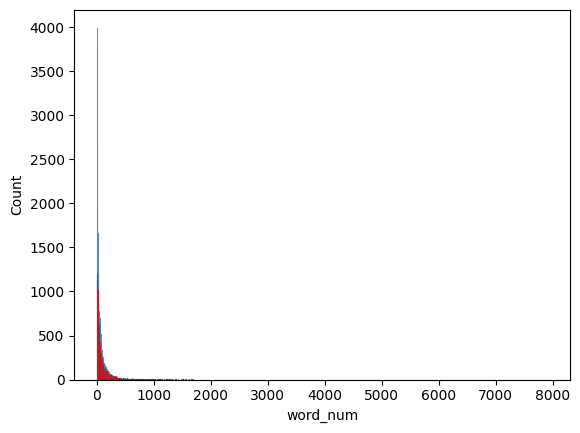

In [ ]:
sns.histplot(new_df[new_df['target'] == 1]['word_num'])
sns.histplot(new_df[new_df['target'] == -1]['word_num'],color='red')

plt.show()


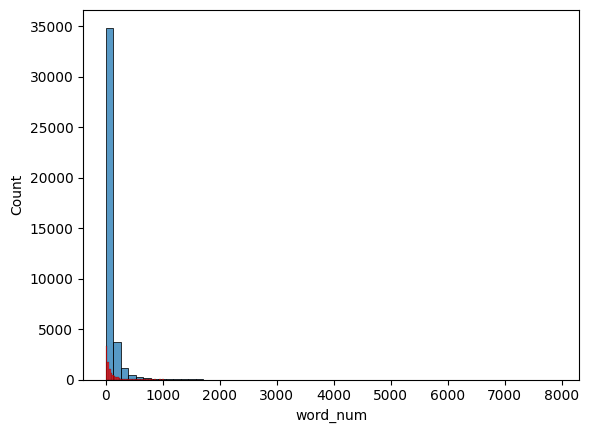

In [ ]:
#Versão limitando eixo X:

sns.histplot(new_df[new_df['target'] == 1]['word_num'], bins=60)
sns.histplot(new_df[new_df['target'] == -1]['word_num'], bins=60,color='red')

plt.show()

Mesmo raciocínio para `word_num`.

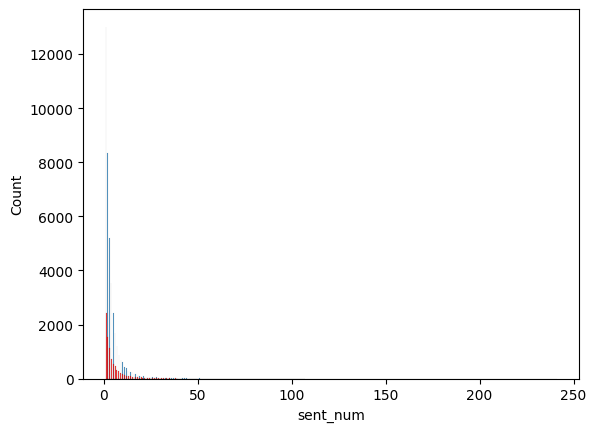

In [ ]:
sns.histplot(new_df[new_df['target'] == 1]['sent_num'])
sns.histplot(new_df[new_df['target'] == -1]['sent_num'],color='red')

plt.show()


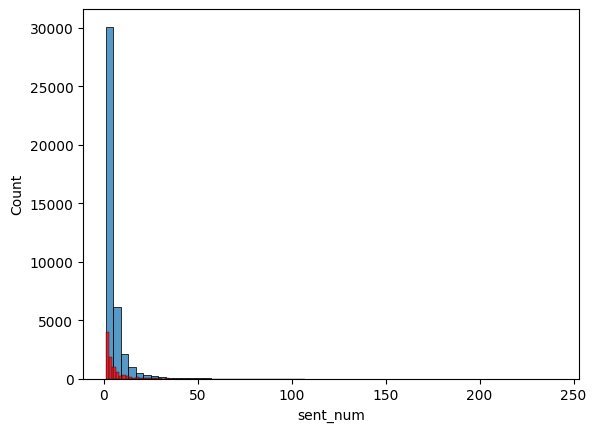

In [ ]:
# Limitando o eixo X novamente:

sns.histplot(new_df[new_df['target'] == 1]['sent_num'], bins=60)
sns.histplot(new_df[new_df['target'] == -1]['sent_num'], bins=60, color='red')

plt.show()

E agora para `sent_num`.

#**SESSÃO 3: PRÉ-PROCESSAMENTO DE TEXTO**

**Objetivo da etapa:**

Nesta etapa, transformamos os textos brutos das reviews em uma versão “limpa” e padronizada, mais adequada para ser usada como entrada em modelos de Machine Learning.

A ideia é reduzir ruído (pontuação, palavras muito comuns) e aproximar palavras que têm a mesma raiz (ex.: `playing, played, plays → play`), para que o modelo foque mais no conteúdo do que em variações de escrita.

**Usaremos as seguintes técnicas de NLP:**



1.   `Lower case`
2.   `Tokenization`
3.   `Removing special characters`
4.   `Removing stop words and punctuation`
5.   `stemming`




Usamos a biblioteca NLTK para `tokenização` (quebrar texto em palavras/sentenças) e para acessar a lista de stopwords.
Também usamos:

`PorterStemmer`: para reduzir palavras ao seu “radical” (stemming)

`string.punctuation`: para remover pontuações

`WordCloud + matplotlib`: apenas para visualização das palavras mais frequentes.

As stopwords usadas aqui são em inglês, pois as reviews da Steam estão nesse idioma.

# **3.1) Imports necessários nessa etapa e setups**

usaremos os recursos da library `NLTK` para tokenização e listar stopwords

In [ ]:
#import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
"""
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import string
"""

'\nfrom nltk.corpus import stopwords\nfrom nltk.stem.porter import PorterStemmer\nimport string\n'

In [ ]:
#from wordcloud import WordCloud
#import matplotlib.pyplot as plt

`stopwords`: lista de palavras muito comuns que não carregam informação útil para sentimento `(the, for, as, it, etc)`.

`PorterStemmer`: faz stemming `(reduz palavras ao que o código entender como "radical")`.

`string`: usado para pegar pontuação `(string.punctuation)`.

In [ ]:
ps = PorterStemmer()

Instancia o `stemmer`.

In [ ]:
stop = set(stopwords.words('english'))
punct = set(string.punctuation)

Cria o conjunto de `stopwords` em inglês.

Cria o conjunto de pontuações. Conjuntos são a estrutura de dados usada porque verificações do tipo “pertence/contém” é de complexidade linear no pior caso, então os filtros ficam rápidos.

# **3.2. Função de limpeza**

A função abaixo recebe uma review em texto bruto e aplica as seguintes etapas:

Converte tudo para minúsculo `(lowercase)`.

Tokeniza o texto em palavras.

Remove:

`stopwords` em inglês (palavras muito frequentes e pouco informativas, como `the`, `is`, `at`);

pontuação.

Aplica `stemming` com o `PorterStemmer`, reduzindo as palavras a uma forma de raiz.

Junta os tokens novamente em uma única string, que será utilizada pelo vetorizador.

In [ ]:
def convert_text(text: str) -> str: #Essa seta (->) serve para indicar o tipo de dado que a função retorna,
#um jeito de forçar a tipagem estática no python.
    """
    Recebe um texto cru e devolve uma string:
    - sem minúsculas
    - sem stopwords
    - sem pontuação
    - com stemming (PorterStemmer)
    """
    if not isinstance(text, str):
        text = str(text)

    # lowercase
    text = text.lower()

    # tokenização
    tokens = nltk.word_tokenize(text)

    # filtra stopwords e pontuação + aplica stemming
    stemmed_tokens = [
        ps.stem(tok)
        for tok in tokens
        if tok not in stop and tok not in punct
    ]

    # junta de volta em uma string
    return " ".join(stemmed_tokens)

# **3.3. Aplicação no DataFrame**

Antes de aplicar o pré-processamento em massa, consultamos uma review individual para ter ideia de como o texto original está organizado (gírias, tamanho, presença de pontuações, etc.).

Em seguida, aplicamos a função `convert_text` em toda a coluna `text`, criando a nova coluna `converted_text`, que será a base para representar os textos numericamente (`Bag of Words`) nas próximas etapas.

consultando uma review aleatória só pra conferir como está antes de aplicar qualquer coisa:

In [ ]:
new_df['text'].head()

,text
6038558,i learned more russian playing 18 hrs than 4 y...
3755002,All I have to say is this game is amazing!!!!
1109815,Update! Overkill have decided that any brainl...
5365130,*teleports behind you* MIETA 10/10
877802,An unbelievably deep and rewarding game. I can...


Aplicando a função que construímos:

In [ ]:
new_df['converted_text']=new_df['text'].apply(convert_text)

Cria a coluna `converted_text` com o resultado da limpeza para cada review.

In [ ]:
new_df.head()

,target,text,char_num,word_num,sent_num,converted_text
6038558,1,i learned more russian playing 18 hrs than 4 y...,80,17,2,learn russian play 18 hr 4 year russian class ...
3755002,1,All I have to say is this game is amazing!!!!,45,14,2,say game amaz
1109815,-1,Update! Overkill have decided that any brainl...,3993,798,35,updat overkil decid brainless gibbon abl win e...
5365130,1,*teleports behind you* MIETA 10/10,34,7,1,teleport behind mieta 10/10
877802,1,An unbelievably deep and rewarding game. I can...,77,15,2,unbeliev deep reward game recommend highli enough


# **3.4. Word clouds (diagnóstico visual)**

As word clouds abaixo mostram as palavras mais frequentes em reviews positivas e negativas, depois do pré-processamento.

A ideia aqui não é treinar modelo, mas:

**verificar se há termos claramente associados a cada classe;**

**ter uma visão qualitativa do vocabulário;**

**identificar possíveis ruídos (palavras muito frequentes que talvez ainda devessem ser removidas).**

Esse tipo de visualização ajuda a “enxergar” o dataset de forma mais intuitiva antes de partir de vez para o modelo.

In [ ]:
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')


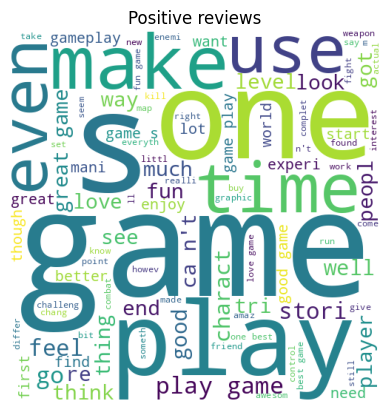

In [ ]:
pos_blob = new_df.loc[new_df['target'] == 1, 'converted_text'].str.cat(sep=" ")
pos_wc = wc.generate(pos_blob)
plt.imshow(pos_wc)
plt.axis('off')
plt.title('Positive reviews')
plt.show()


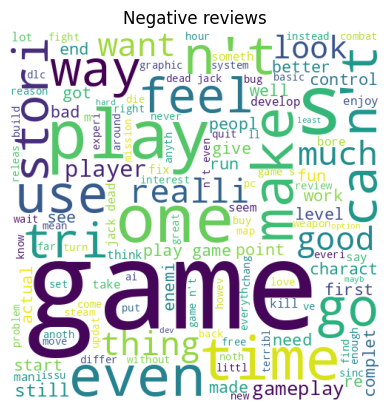

In [ ]:
neg_blob = new_df.loc[new_df['target'] == -1, 'converted_text'].str.cat(sep=" ")
neg_wc = wc.generate(neg_blob)
plt.imshow(neg_wc)
plt.axis('off')
plt.title('Negative reviews')
plt.show()

# **SESSÃO 4, CONSTRUINDO O MODELO**

## **Representação do texto e separação treino/teste**

#**4.1 – Vetorização (Bag of Words)**



Essa parte é fundamental e pode soar complexa olhando só para os códigos. Sendo assim, segue uma explicação detalhada com exemplos hipotéticos:

**Passo 1: montar o vocabulário**

Entregamos TODAS as reviews para o `CountVectorizer`.

 Ele faz:

1. varre todos os textos

2. conta todas as palavras que aparecem

3. escolhe, por exemplo, as 3.000 mais frequentes

cria um vocabulário, que é basicamente um dicionário:

In [ ]:
"""

Exemplo:

índice → palavra

0 → game
1 → play
2 → bad
3 → good
...
2999 → whatever

"""

'\n\nExemplo:\n\níndice → palavra\n\n0 → game\n1 → play\n2 → bad\n3 → good\n...\n2999 → whatever\n\n'

**Passo 2: transformar UMA review em vetor**

Agora pega uma review só, tipo:

"this game is good, good, good"

Depois do pré-processamento, digamos que vire:

"game good good good"

Com o vocabulário acima, o CountVectorizer transforma essa review em um vetor do tipo:

In [ ]:
"""

[1, 0, 0, 3, 0, 0, ..., 0]

"""

'\n\n[1, 0, 0, 3, 0, 0, ..., 0]\n\n'

Interpretação:

`posição 0 → palavra "game" → aparece 1 vez`

`posição 3 → palavra "good" → aparece 3 vezes`

o resto é zero (palavras que não apareceram nessa review)

Ou seja, para cada review, você tem um vetor com tamanho igual ao número de palavras do vocabulário armazenado no dicionário criado na etapa anterior.

**Passo 3: empilhar todos os vetores**

Agora imagina que você tem 4 reviews, e o vocabulário tem 4 palavras, só pra ficar visual:

Vocabulário:

In [ ]:
"""

0 → game
1 → good
2 → bad
3 → boring

"""

'\n\n0 → game\n1 → good\n2 → bad\n3 → boring\n\n'

Reviews (depois do pré-processamento):

`"good game"`

`"bad game boring"`

`"good good game"`

`"boring"`

Vetores de cada review:

`[1, 1, 0, 0]`

`[1, 0, 1, 1]`

`[1, 2, 0, 0]`

`[0, 0, 0, 1]`

Quando você empilha isso, vira a famosa matriz X:

In [ ]:
"""
          game  good  bad  boring
rev1  →   [ 1 ,  1 ,  0 ,   0  ]
rev2  →   [ 1 ,  0 ,  1 ,   1  ]
rev3  →   [ 1 ,  2 ,  0 ,   0  ]
rev4  →   [ 0 ,  0 ,  0 ,   1  ]

"""

'\n          game  good  bad  boring\nrev1  →   [ 1 ,  1 ,  0 ,   0  ]\nrev2  →   [ 1 ,  0 ,  1 ,   1  ]\nrev3  →   [ 1 ,  2 ,  0 ,   0  ]\nrev4  →   [ 0 ,  0 ,  0 ,   1  ]\n\n'

Ou seja:

`linhas = reviews`

`colunas = palavras do vocabulário`

`cada célula = frequência daquela palavra naquela review`

Em código, a linha a seguir faz os 3 passos de uma vez:


`monta vocabulário → cria vetor por review → empilha numa matriz.`

In [ ]:
#CountVectorizer().fit_transform(lista_de_reviews)

# **4.2 Aplicação prática**

In [ ]:
#from sklearn.feature_extraction.text import CountVectorizer

Importa o vetorizador clássico para contar ocorrências `(Bag of Words)`.

In [ ]:
cv = CountVectorizer(max_features=3000)


Instancia o  conjunto (logo logo vai se transformar em vetor) para armazenar a Count de palavras.

max_features: limita o vocabulário para reduzir dimensionalidade e RAM.



In [ ]:
X = cv.fit_transform(new_df['converted_text']).toarray()


Transforma a coluna pré-processada `(converted_text)` em matriz de contagens: `linhas = reviews`, `colunas = termos`.

`fit_transform` aprende o vocabulário e gera as features.

In [ ]:
X.shape

(50000, 3000)

In [ ]:
y = new_df['target'].values

Vetor de rótulos com `−1` e `1`.

In [ ]:
y

array([ 1,  1, -1, ...,  1, -1,  1])

In [ ]:
#from sklearn.model_selection import train_test_split

Importa o utilitário para separar treino e teste.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2,random_state = 34)

Para avaliar o desempenho do modelo de forma justa, dividimos os dados em:

treino: `80% das reviews`;

teste: `20% das reviews`.

O modelo é ajustado apenas com os dados de treino e, depois, testado em dados que ele nunca “viu” antes.

É mais justo fazer dessa forma pois as funções `train_test_split` costumam pegar amostras de tamanho aleatório para treinar, quem decide essa aleatoriedade é um gerador de números aleatórios interno. Isso poderia causar ruídos estatísticos no modelo, por isso, definimos deterministicamente a divisão `80/20`.

Definimos também um `random_state` fixo para garantir que a divisão seja reprodutível:

In [ ]:
#random_state = 34

Computador não “sorteia” de verdade, ele faz pseudorrandômico:

Existe uma fórmula determinística (um algoritmo) que gera uma sequência de números.

Essa fórmula precisa de um valor inicial, que é a semente (`seed`).

Se você usar a mesma semente, a mesma sequência de “números aleatórios” é gerada.

Se mudar a semente, muda a sequência.

No caso, nossa `seed` é o `random_state`.

In [ ]:
X_train.shape #essa é a matriz de treino no formado review x palavra criado pelo CountVetorizer lá atrás.

(40000, 3000)

In [ ]:
y_train.shape #Essa é a matriz de treino do vetor Y que contém os scores das avaliações, se são positivas ou negativas.

(40000,)

In [ ]:
X_test.shape #essa é a matriz de Teste de X.

(10000, 3000)

In [ ]:
y_test.shape #essa é a matriz de Teste de Y.

(10000,)

# **SESSÃO 5: AVALIAÇÃO DOS MODELOS**

# **Imports dos classificadores e métricas**

In [ ]:
#from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
#from sklearn.metrics import accuracy_score, confusion_matrix, precision_score


Importa as três variantes do NB que ele compara.

Traz métricas básicas: acurácia, matriz de confusão e precisão.

Observação rápida: para contagens `(CountVectorizer)`, o mais adequado costuma ser `MultinomialNB`. `BernoulliNB` também vai bem se você binariza presença/ausência. `GaussianNB` assume distribuição normal contínua, o que não combina com contagens, mas ele testou mesmo assim.

# **5.1 Modelo Usado: Naive Bayes**

`Naive Bayes` é uma família de modelos de classificação probabilísticos que parte de uma suposição bem otimista:

as features são independentes entre si dado a classe. “`Naive`” (ingênuo) por isso mesmo.

Na prática, ele usa a regra de Bayes para calcular, para cada classe, a probabilidade de um exemplo pertencer a ela a partir das evidências (as `features`).

Em texto, por exemplo, ele calcula algo como:

* “qual a probabilidade dessa review ser positiva dado que aparecem essas palavras?”.

Mesmo a suposição de independência sendo claramente falsa em linguagem natural, o modelo costuma funcionar muito bem em tarefas como classificação de documentos, spam, análise de sentimento etc., e tem duas vantagens enormes: é simples e muito rápido, mesmo com muitos dados.

#**5.1 – Por que Naive Bayes?**

Nesta etapa, avaliamos o desempenho de modelos da família Naive Bayes para a tarefa de classificação de sentimento das reviews.

Esse tipo de modelo é muito usado em problemas de texto porque:

1. é simples de implementar;

2. é rápido para treinar mesmo em bases grandes;

3. funciona bem com representações tipo `Bag of Words`, em que cada feature é uma contagem de palavra.

A suposição “`naive`” (ingênua) é que as features são condicionalmente independentes entre si dado a classe. Na prática isso não é verdade para texto, mas, mesmo assim, o modelo costuma funcionar bem na maioria dos cenários de classificação de documentos.

# **5.2 GaussianNB: Distribuição Normal (neste caso, discreta)**

Assume que cada feature segue uma distribuição normal contínua. É mais adequado para dados numéricos reais (como medidas físicas) e menos alinhado com contagens inteiras de palavras. Foi incluído apenas como comparação.

In [ ]:
gnb = GaussianNB()

Cria o classificador Gaussiano e treina com as features e rótulos de treino.

# **5.3 MultinomialNB: Distribuição Multinomial**

É o modelo mais adequado para contagens de palavras geradas pelo `CountVectorizer`.
Considera que, para cada classe (review positiva ou negativa), existe uma distribuição de probabilidade sobre o vocabulário, e a review é vista como uma sequência de “sorteios” dessas palavras. É o modelo mais comum em classificação de texto com `Bag of Words`.

In [ ]:

mnb = MultinomialNB()

# **5.4 BernoulliNB: Distribuição de Bernoulli**

Trabalha melhor com features binárias, quando o que importa é a presença ou ausência de uma palavra na review (e não quantas vezes ela apareceu). Também pode ser aplicado a contagens, mas sua hipótese original está mais ligada a vetores `0/1`

In [ ]:

bnb = BernoulliNB()


# **5.5 Métricas de avaliação**

Para comparar os modelos, utilizamos três métricas principais:

**1. Acurácia** `(accuracy_score)`:

Proporção de previsões corretas no conjunto de teste.

**2. Matriz de confusão** `(confusion_matrix)`:

Mostra, para cada classe, quantos exemplos foram corretamente classificados e quantos foram confundidos com a outra classe. Na ordem padrão do `scikit-learn`, a matriz é:

In [ ]:

"""
[ TN ,  FP ]
[ FN ,  TP ]

"""

'\n[ TN ,  FP ]\n[ FN ,  TP ]\n\n'

em que:

`TN` = verdadeiros negativos

`FP` = falsos positivos

`FN` = falsos negativos

`TP` = verdadeiros positivos

**3. Precisão** `(precision_score)` **da classe positiva (1)**

Mede, entre todas as reviews previstas como positivas, qual fração é de fato positiva:

In [ ]:
#Precisão = TP / (TP + FP)

#**5.6 Função para selecionar e avaliar um entre os 3 modelos:**

In [ ]:
def avaliar_modelo(nome, modelo, X_train, y_train, X_test, y_test):
    """
    Treina um modelo, faz previsões no teste
    e mostra acurácia, matriz de confusão e precisão.
    """

    # treina o modelo com os dados de treino
    modelo.fit(X_train, y_train)

    # faz previsões para os dados de teste
    y_pred = modelo.predict(X_test)

    # calcula as métricas básicas
    acc  = accuracy_score(y_test, y_pred)      # % de acertos
    cm   = confusion_matrix(y_test, y_pred)    # tabela de acertos/erros por classe
    prec = precision_score(y_test, y_pred)     # qualidade das previsões positivas

    # imprime tudo de forma organizada
    print(f"=== {nome} ===")
    print(f"Acurácia: {acc:.4f}")
    print("Matriz de confusão:")
    print(cm)
    print(f"Precisão (classe positiva = 1): {prec:.4f}")
    print()

    # devolve o modelo treinado e as previsões, se quisermos usar depois
    return modelo, y_pred


# usando a função para os três Naive Bayes
gnb, y_pred_gnb = avaliar_modelo(
    "GaussianNB",
    GaussianNB(),
    X_train, y_train,
    X_test, y_test
)

mnb, y_pred_mnb = avaliar_modelo(
    "MultinomialNB",
    MultinomialNB(),
    X_train, y_train,
    X_test, y_test
)

bnb, y_pred_bnb = avaliar_modelo(
    "BernoulliNB",
    BernoulliNB(),
    X_train, y_train,
    X_test, y_test
)

=== GaussianNB ===
Acurácia: 0.7895
Matriz de confusão:
[[ 711 1094]
 [1011 7184]]
Precisão (classe positiva = 1): 0.8678

=== MultinomialNB ===
Acurácia: 0.8702
Matriz de confusão:
[[1013  792]
 [ 506 7689]]
Precisão (classe positiva = 1): 0.9066

=== BernoulliNB ===
Acurácia: 0.7795
Matriz de confusão:
[[ 736 1069]
 [1136 7059]]
Precisão (classe positiva = 1): 0.8685



# **5.7 Comentário de escolha**

\com `CountVectorizer`, o melhor entre os três foi `MultinomialNB`. É a conclusão operacional dele.

`MultinomialNB ≥ BernoulliNB ou GaussianNB`

#**SESSÃO 6: TESTE FINAL**

Nesta última etapa, montamos um **pipeline completo** de processamento e classificação de texto, combinando em um único objeto:

1. A etapa de **vetorização** (Bag of Words com `CountVectorizer`);  
2. O **modelo de classificação** escolhido na sessão anterior (`MultinomialNB`).

A ideia do pipeline é facilitar o uso do modelo em ambiente real: em vez de chamar manualmente cada etapa (pré-processamento → vetorização → predição), treinamos tudo em conjunto e usamos uma única interface para prever o sentimento de novas reviews.

Usamos como entrada a coluna `converted_text`, que já contém os textos pré-processados pela função `convert_text`. Em seguida:

- dividimos os dados novamente em treino e teste, diretamente no nível de texto;  
- treinamos o pipeline (`CountVectorizer + MultinomialNB`) com os textos de treino;  
- implementamos a função `checker_pipeline(text)`, que:
  - recebe uma frase nova em inglês,
  - aplica o mesmo pré-processamento,
  - e retorna se a review seria considerada **positiva** ou **negativa** pelo modelo.


# **6.1 Teste com entradas novas**

In [ ]:
# textos já pré-processados (convert_text foi aplicada antes para gerar 'converted_text')
X_text = new_df['converted_text'].values
y = new_df['target'].values

# pipeline final: Bag of Words + MultinomialNB
pipe = make_pipeline(
    CountVectorizer(max_features=3000),
    MultinomialNB()
)

# treina o modelo final em TODO o conjunto rotulado
pipe.fit(X_text, y)

def checker(text):
    """
    Recebe uma frase em inglês e retorna a classificação de sentimento.
    Usa o mesmo pré-processamento (convert_text) e o pipeline treinado.
    """
    # garante que 'text' seja string
    clean = convert_text(text or "")

    # o pipeline espera uma lista de textos
    pred = pipe.predict([clean])[0]

    if pred == 1:
        return "Positive Review (recomenda o jogo)"
    else:
        return "Negative Review (não recomenda o jogo)"


Usos da função em frases novas:

In [ ]:
checker('game is a waste of time')

'Negative Review (não recomenda o jogo)'

In [ ]:
checker('I really loved this game')

'Positive Review (recomenda o jogo)'

In [ ]:
checker('Easy to learn, hard to master.') #realmente é positiva no dataset original

'Positive Review (recomenda o jogo)'

In [ ]:
checker('What am I supposed to say? I made a mistake')

'Positive Review (recomenda o jogo)'

In [ ]:
checker('This game ruined my life') #Por incrível que pareça, é positiva no dataset original

'Positive Review (recomenda o jogo)'

In [ ]:
checker('This game ruined my life') #Por incrível que pareça, é positiva no dataset original

'Positive Review (recomenda o jogo)'

# **SESSÃO 7: TRANSPORTANDO PARA O BACKEND**

Cria uma pasta models:

In [ ]:
import os

os.makedirs("models", exist_ok=True)



A função `joblib.dump()` é utilizada para serializar e salvar objetos Python arbitrários em um arquivo no disco.

In [ ]:


import joblib
# nomes mais "bonitinhos" pros objetos
vectorizer = cv              # CountVectorizer treinado
modelGNB = gnb               # GaussianNB treinado
modelMNB = mnb               # MultinomialNB treinado
modelBNB = bnb               # BernoulliNB treinado
sentiment_pipeline = pipe    # Pipeline (CountVectorizer + MultinomialNB)

# salva cada um em um arquivo .pkl
joblib.dump(vectorizer,         "models/cv.pkl")
joblib.dump(modelGNB,           "models/gnb.pkl")
joblib.dump(modelMNB,           "models/mnb.pkl")
joblib.dump(modelBNB,           "models/bnb.pkl")
joblib.dump(sentiment_pipeline, "models/nb_pipeline.pkl")


['models/nb_pipeline.pkl']

`nb_pipeline.pkl` (o `sentiment_pipeline`) = vetorizador + modelo amarrados num objeto só

In [ ]:
#baixando a pasta:

!zip -r /content/arquivo_compactado.zip /content/models
+
78I9O0´~]


  adding: content/models/ (stored 0%)
  adding: content/models/gnb.pkl (deflated 43%)
  adding: content/models/nb_pipeline.pkl (deflated 68%)
  adding: content/models/cv.pkl (deflated 72%)
  adding: content/models/bnb.pkl (deflated 69%)
  adding: content/models/mnb.pkl (deflated 68%)


In [ ]:
from google.colab import files
files.download('/content/arquivo_compactado.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>